<a href="https://colab.research.google.com/github/AbhinavKumar0000/Machine_learning/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

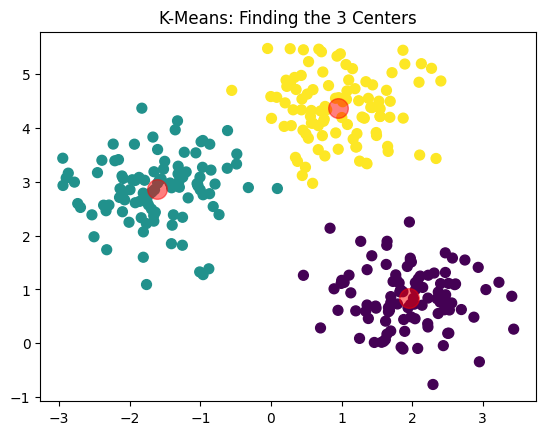

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Create 3 random blobs of data
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=0)

# Apply K-Means
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5) # The Centroids
plt.title("K-Means: Finding the 3 Centers")
plt.show()

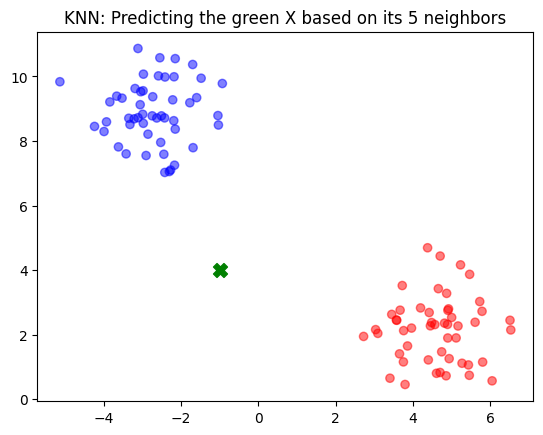

In [2]:
from sklearn.neighbors import KNeighborsClassifier

# Create data with two clear classes (Red and Blue)
X_train, y_train = make_blobs(n_samples=100, centers=2, random_state=42)
new_point = [[-1, 4]]

# Apply KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
prediction = knn.predict(new_point)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', alpha=0.5)
plt.scatter(new_point[0][0], new_point[0][1], c='green', s=100, marker='X') # The Query Point
plt.title(f"KNN: Predicting the green X based on its 5 neighbors")
plt.show()

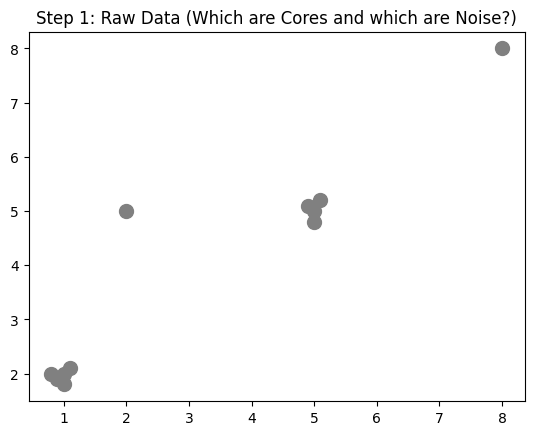

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Create a dense cluster + 2 noise points
X = np.array([[1, 2], [1.1, 2.1], [0.9, 1.9], [1, 1.8], [0.8, 2], # Cluster 1
              [5, 5], [5.1, 5.2], [4.9, 5.1], [5, 4.8],           # Cluster 2
              [2, 5], [8, 8]])                                    # Outliers/Noise

plt.scatter(X[:, 0], X[:, 1], c='gray', s=100)
plt.title("Step 1: Raw Data (Which are Cores and which are Noise?)")
plt.show()

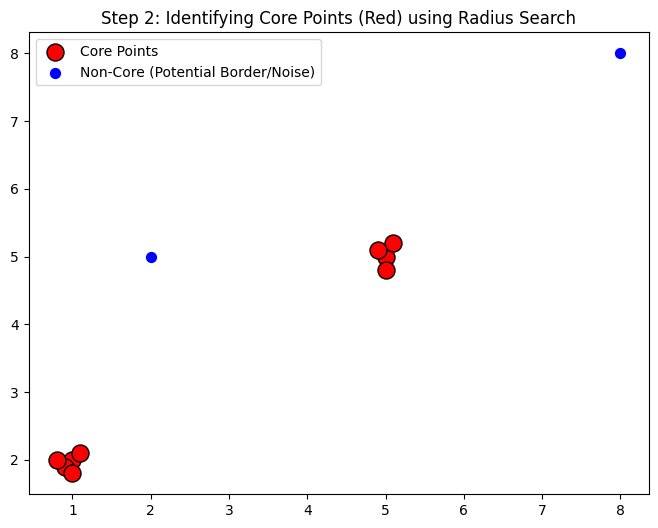

In [4]:
from sklearn.cluster import DBSCAN

# Define parameters
eps_val = 1.0
min_pts = 4

db = DBSCAN(eps=eps_val, min_samples=min_pts).fit(X)

# Logic to identify types
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Plotting
plt.figure(figsize=(8, 6))

# 1. Plot Core Points (Large circles)
plt.scatter(X[core_samples_mask, 0], X[core_samples_mask, 1],
            c='red', s=150, label='Core Points', edgecolors='k')

# 2. Plot Non-Core Points (Small circles)
plt.scatter(X[~core_samples_mask, 0], X[~core_samples_mask, 1],
            c='blue', s=50, label='Non-Core (Potential Border/Noise)')

plt.legend()
plt.title("Step 2: Identifying Core Points (Red) using Radius Search")
plt.show()

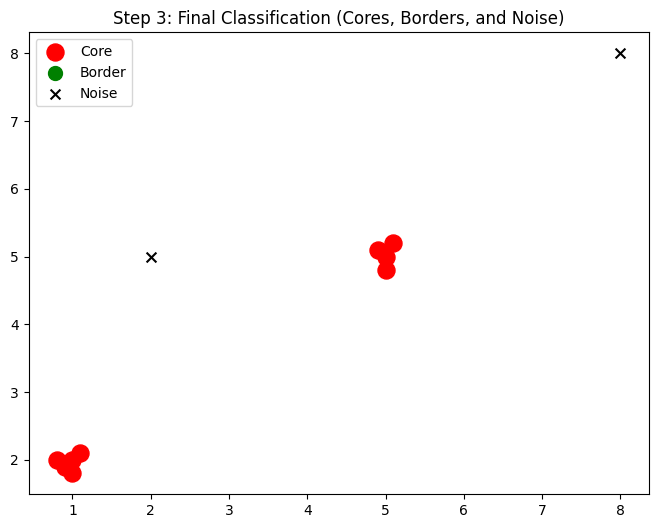

In [5]:
# Labels: -1 means Noise, 0 or higher means a Cluster
is_noise = labels == -1
is_border = (~core_samples_mask) & (~is_noise)

plt.figure(figsize=(8, 6))

# Plot Cores
plt.scatter(X[core_samples_mask, 0], X[core_samples_mask, 1], c='red', s=150, label='Core')
# Plot Borders
plt.scatter(X[is_border, 0], X[is_border, 1], c='green', s=100, label='Border')
# Plot Noise
plt.scatter(X[is_noise, 0], X[is_noise, 1], c='black', s=50, marker='x', label='Noise')

plt.title("Step 3: Final Classification (Cores, Borders, and Noise)")
plt.legend()
plt.show()

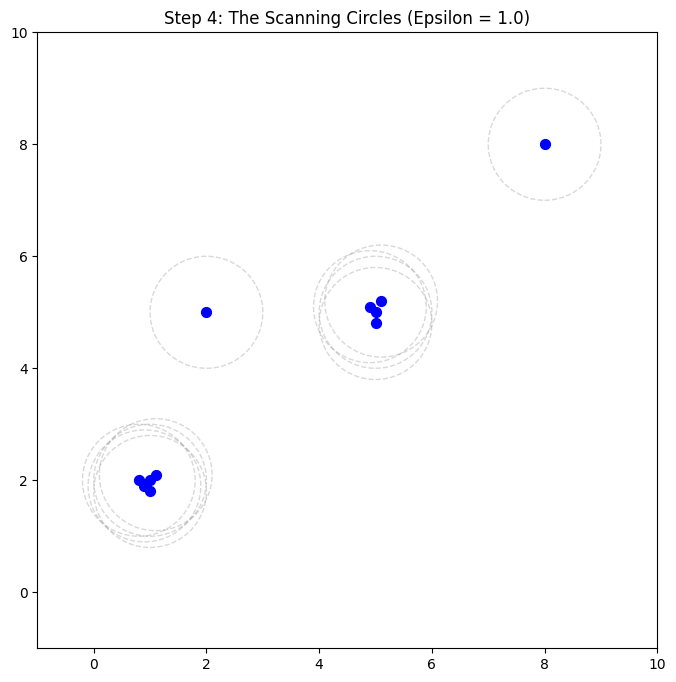

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1], c='blue', s=50)

# Draw the Epsilon circle around every point
for point in X:
    circle = plt.Circle((point[0], point[1]), eps_val, color='gray', fill=False, linestyle='--', alpha=0.3)
    ax.add_artist(circle)

plt.xlim(-1, 10); plt.ylim(-1, 10)
plt.title(f"Step 4: The Scanning Circles (Epsilon = {eps_val})")
plt.show()

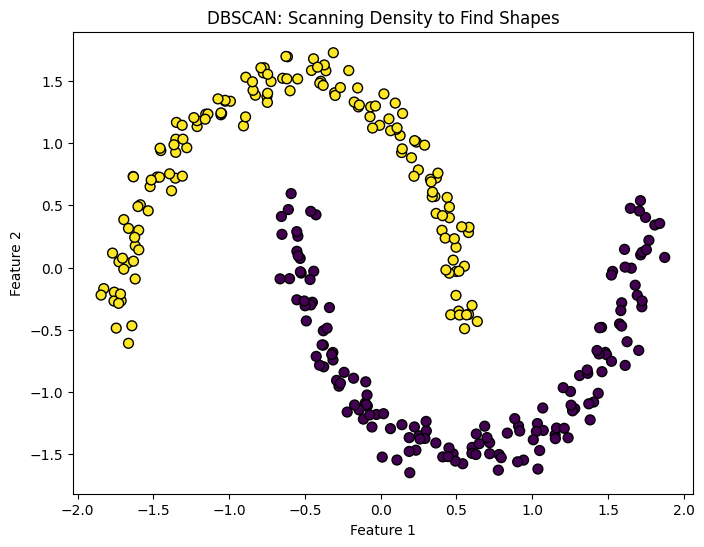

Number of noise points detected: 0


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. DATASET: Two interlocking moons (K-Means would fail here)
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)
X = StandardScaler().fit_transform(X) # Scaling is CRITICAL for distance-based models

# 2. THE SCAN: Apply DBSCAN
# eps: The size of the scanning circle
# min_samples: Min points to be a 'Core' point
dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X)

# 3. PLOT: Visualizing the groups
plt.figure(figsize=(8, 6))

# Points labeled -1 are NOISE (Black)
# Others are colored by cluster ID
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50, edgecolors='k')

plt.title("DBSCAN: Scanning Density to Find Shapes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Counting noise
n_noise = list(clusters).count(-1)
print(f"Number of noise points detected: {n_noise}")